# Homework 08: Exploratory Data Analysis
A reproducible EDA of the provided AAPL daily close series.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
P=Path.cwd().resolve(); P=P if P.name=='homework08' else P/'homework'/'homework08'
sys.path.insert(0,str(P))
from src.eda import eda_summary

Matplotlib is building the font cache; this may take a moment.


## Data and profiling

In [2]:
df=pd.read_csv(P/'data/raw/aapl_prices.csv',parse_dates=['date']).sort_values('date')
df['return']=df['close'].pct_change()
df['rolling_vol_20']=df['return'].rolling(20).std()
df['ma_20']=df['close'].rolling(20).mean()
df['day_name']=df['date'].dt.day_name()
print(df.info())
display(df.describe(include='all',datetime_is_numeric=True) if 'datetime_is_numeric' in __import__('inspect').signature(df.describe).parameters else df.describe(include='all'))
display(df.isna().sum().to_frame('missing'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            252 non-null    datetime64[ns]
 1   close           252 non-null    float64       
 2   return          251 non-null    float64       
 3   rolling_vol_20  232 non-null    float64       
 4   ma_20           233 non-null    float64       
 5   day_name        252 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 11.9+ KB
None


,date,close,return,rolling_vol_20,ma_20,day_name
count,252,252.000000,251.000000,232.000000,233.000000,252
unique,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,Tuesday
freq,NaN,NaN,NaN,NaN,NaN,53
mean,2026-02-24 12:28:34.285714176,275.634404,0.001362,0.015191,275.949480,NaN
min,2025-08-26 00:00:00,226.789993,-0.073539,0.006047,237.150500,NaN
25%,2025-11-23 06:00:00,258.049995,-0.006599,0.011746,259.449500,NaN
50%,2026-02-25 12:00:00,271.035004,0.001274,0.015337,268.800500,NaN
75%,2026-05-27 06:00:00,295.007492,0.009006,0.018369,295.506000,NaN
max,2026-08-26 00:00:00,340.079987,0.048407,0.024386,324.367000,NaN


,missing
date,0
close,0
return,1
rolling_vol_20,20
ma_20,19
day_name,0


In [3]:
profile=eda_summary(df)
display(profile['numeric']); display(profile['missing']); display(profile['attention'])
for column, counts in profile['categorical'].items():
    print(f'Categorical profile: {column}'); display(counts)
shape_stats=df.select_dtypes('number').agg(['skew','kurt']).T
display(shape_stats)

,count,mean,std,min,25%,50%,75%,max
close,252.0,275.634404,25.118296,226.789993,258.049995,271.035004,295.007492,340.079987
return,251.0,0.001362,0.015788,-0.073539,-0.006599,0.001274,0.009006,0.048407
rolling_vol_20,232.0,0.015191,0.004725,0.006047,0.011746,0.015337,0.018369,0.024386
ma_20,233.0,275.949480,22.190735,237.150500,259.449500,268.800500,295.506000,324.367000


,count,pct
date,0,0.000000
close,0,0.000000
return,1,0.003968
rolling_vol_20,20,0.079365
ma_20,19,0.075397
day_name,0,0.000000


,high_missing,near_zero_variance,dominant_category
date,False,False,False
close,False,False,False
return,False,False,False
rolling_vol_20,False,False,False
ma_20,False,False,False
day_name,False,False,False


Categorical profile: date


,count
date,
2025-08-26,1
2026-05-05,1
2026-04-16,1
2026-04-17,1
2026-04-20,1
...,...
2025-12-31,1
2026-01-02,1
2026-01-05,1


Categorical profile: day_name


,count
day_name,
Tuesday,53
Wednesday,53
Thursday,49
Friday,49
Monday,48


,skew,kurt
close,0.511480,-0.422472
return,-0.409393,3.142341
rolling_vol_20,0.132094,-0.794390
ma_20,0.693613,-0.605412


The rolling features contain expected leading missing values rather than data-quality gaps. Return and volatility tails merit robust checks; weekday is balanced enough to encode in Stage 09.

## Distributions

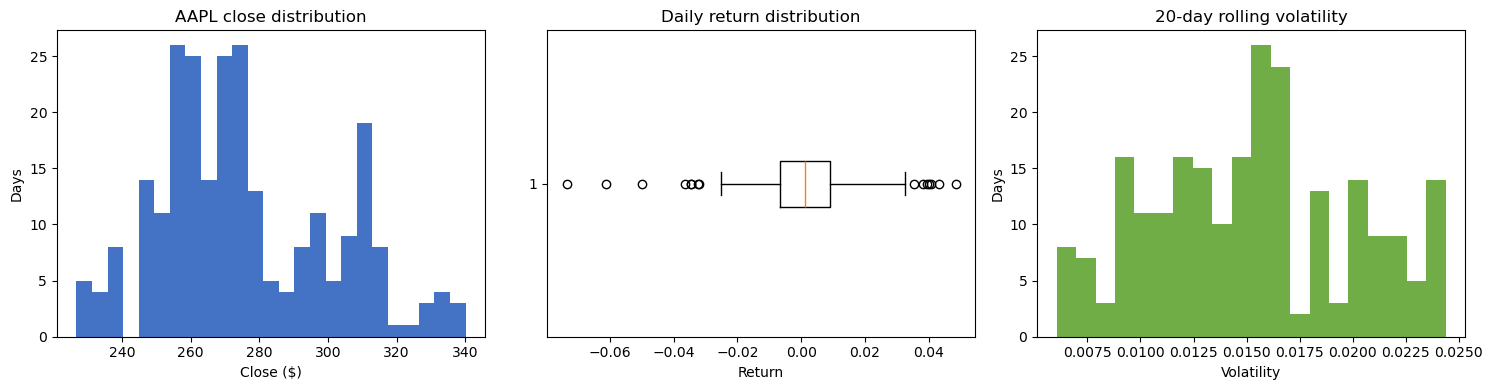

In [4]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
axes[0].hist(df['close'],bins=25,color='#4472C4'); axes[0].set(title='AAPL close distribution',xlabel='Close ($)',ylabel='Days')
axes[1].boxplot(df['return'].dropna(),vert=False); axes[1].set(title='Daily return distribution',xlabel='Return')
axes[2].hist(df['rolling_vol_20'].dropna(),bins=20,color='#70AD47'); axes[2].set(title='20-day rolling volatility',xlabel='Volatility',ylabel='Days')
plt.tight_layout(); plt.show()

Close levels reflect the sampled market regime rather than a stationary distribution. Returns center near zero with tail observations; rolling volatility is positive and right-skewed.

## Relationships and time structure

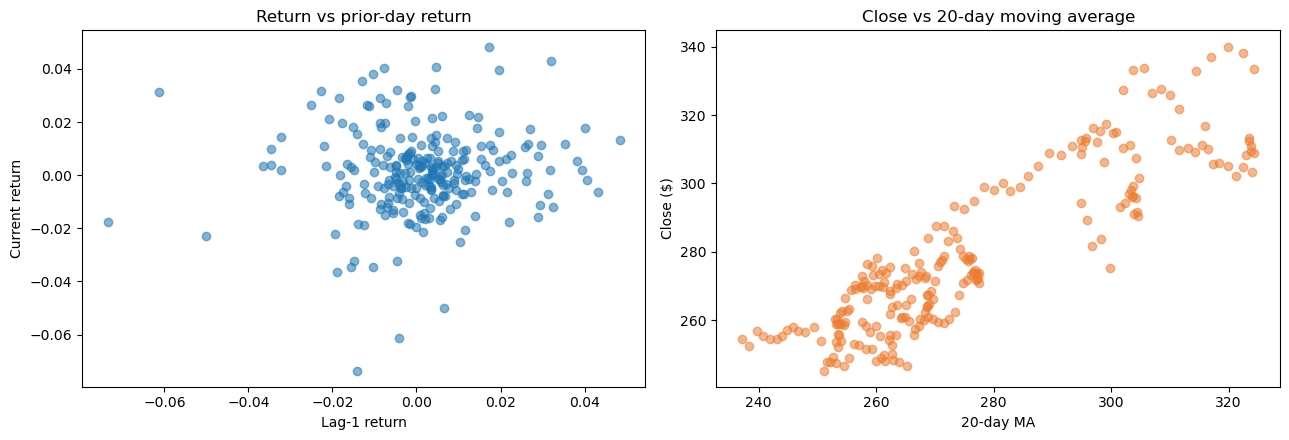

In [5]:
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
axes[0].scatter(df['return'].shift(1),df['return'],alpha=.55); axes[0].set(title='Return vs prior-day return',xlabel='Lag-1 return',ylabel='Current return')
axes[1].scatter(df['ma_20'],df['close'],alpha=.55,color='#ED7D31'); axes[1].set(title='Close vs 20-day moving average',xlabel='20-day MA',ylabel='Close ($)')
plt.tight_layout(); plt.show()

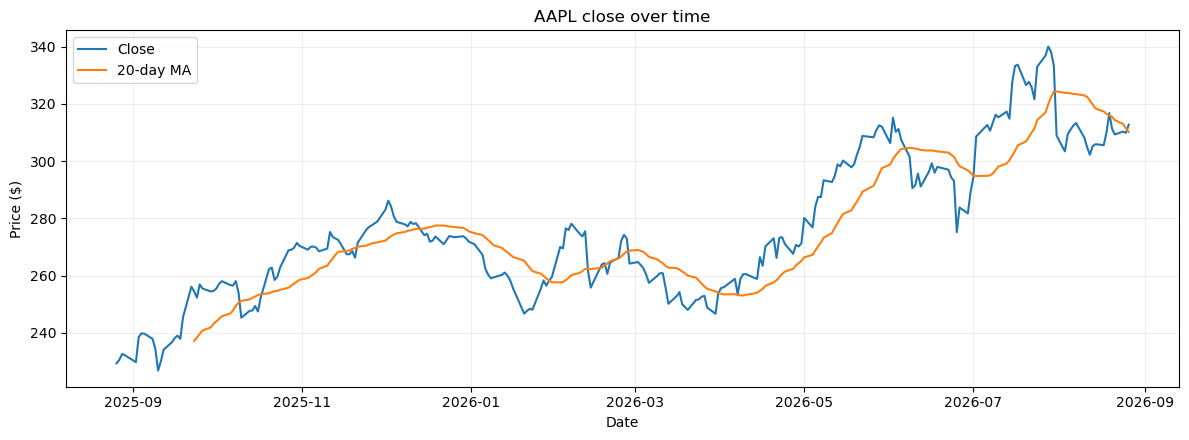

In [6]:
fig,ax=plt.subplots(figsize=(12,4.5)); ax.plot(df['date'],df['close'],label='Close'); ax.plot(df['date'],df['ma_20'],label='20-day MA'); ax.set(title='AAPL close over time',xlabel='Date',ylabel='Price ($)'); ax.legend(); ax.grid(alpha=.2); plt.tight_layout(); plt.show()

The price series shows persistent local trends and changing levels, while returns show little obvious lag-1 linear structure. There is no clear calendar seasonality in this one-year sample. Stage 09 should use lagged return, rolling volatility, momentum, and weekday encoding; Stage 10b must use a chronological split to avoid leakage.

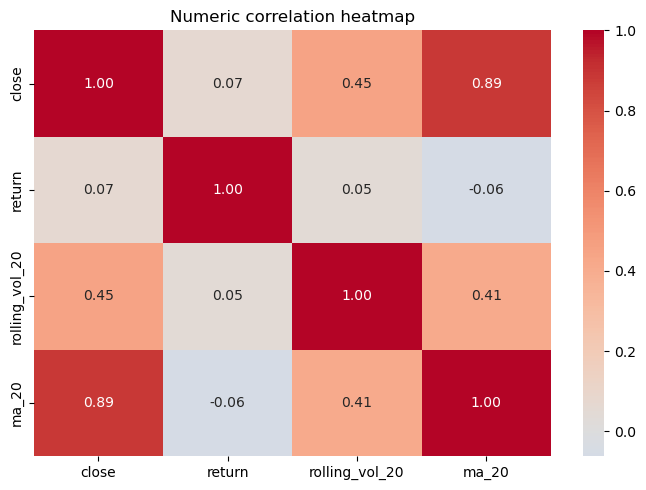

In [7]:
corr=df.select_dtypes('number').corr(); plt.figure(figsize=(7,5)); sns.heatmap(corr,annot=True,cmap='coolwarm',center=0,fmt='.2f'); plt.title('Numeric correlation heatmap'); plt.tight_layout(); plt.show()

## Top 3 insights
1. Price level is nonstationary, so modeling next return is safer than raw price.
2. Time-varying volatility motivates a rolling-risk feature.
3. Weak lag correlation means any prediction baseline should be treated cautiously.

## Assumptions & risks
Adjusted corporate actions are assumed to be reflected in the downloaded close series. One ticker and roughly one year cannot establish stable seasonality or generalize across regimes. Missing rolling values are structural and should be dropped only after feature creation.

## Implications for next step
Engineer strictly lagged return, rolling mean/volatility, five-day momentum, and weekday indicators. Evaluate out of time and avoid using same-day or future information.